🔥 Optimal Operation of a Thermal Cracker Using Linear Programming

Thermal cracking is a key unit operation in the petrochemical and refining industries, where heavy hydrocarbon feedstocks are converted into lighter and more valuable products such as ethylene, propylene, and fuel gases. The profitability of a thermal cracker depends critically on operating decisions including feed rates, product distributions, and capacity utilization, all of which are constrained by material balances and operational limits.

This notebook presents Example 14.1: Optimal Operation of a Thermal Cracker via Linear Programming, adapted from Optimization of Chemical Processes by Edgar, Himmelblau, and Lasdon. The example demonstrates how a realistic chemical process operation problem can be formulated as a linear programming (LP) model and solved efficiently using modern optimization software.

Problem Overview

The thermal cracker is modeled under steady-state conditions with:

fixed yield coefficients,

known product values,

linear relationships between feed flows and product outputs,

and upper and lower bounds on operating variables.

The objective is to determine the optimal operating policy that maximizes economic performance (profit), subject to:

material balance constraints,

capacity and throughput limits,

and operational feasibility constraints.

Because all relationships in the model are linear, the resulting optimization problem is a linear program.

Solution Approach

In this notebook, the LP model is implemented and solved using the Gurobi Optimizer through its Python interface (gurobipy). Gurobi efficiently handles the large but structured constraint system and guarantees global optimality of the solution.

The notebook:

formulates the LP model explicitly,

solves it using Gurobi,

reports the optimal objective value and decision variables,

and interprets the results in terms of process operation and economic trade-offs.

Significance

This example illustrates:

how chemical process flowsheets can be translated into mathematical optimization models,

how economic objectives influence optimal operating decisions,

and how linear programming serves as a foundation for more advanced optimization techniques used in process systems engineering.

The approach demonstrated here provides a clear bridge between chemical process modeling and optimization-based decision making, using a state-of-the-art commercial solver

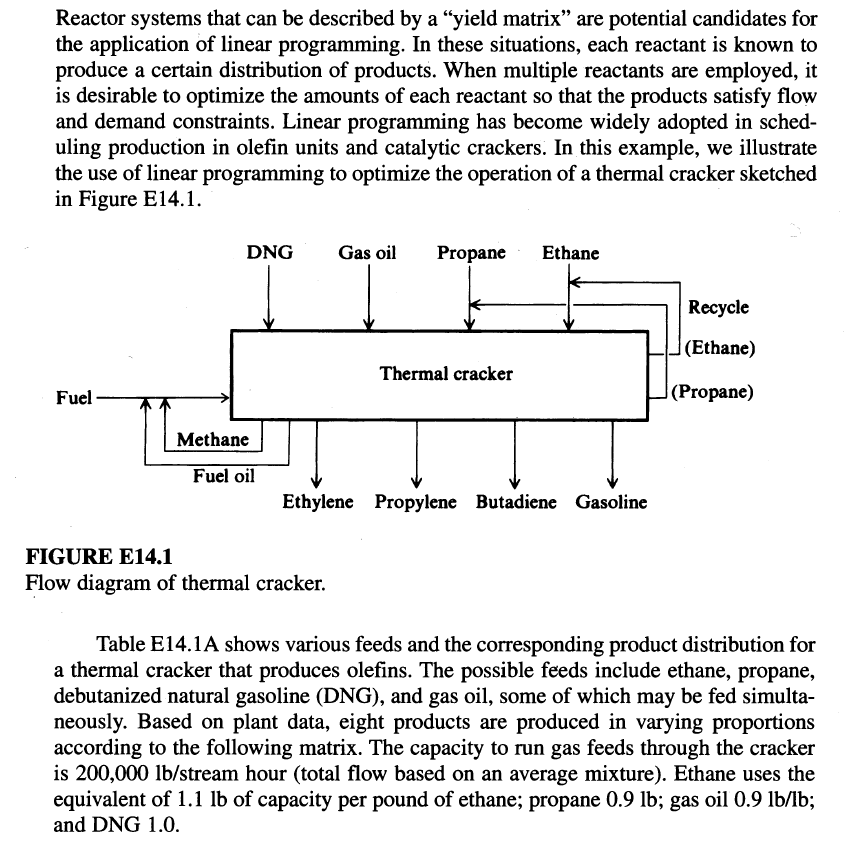

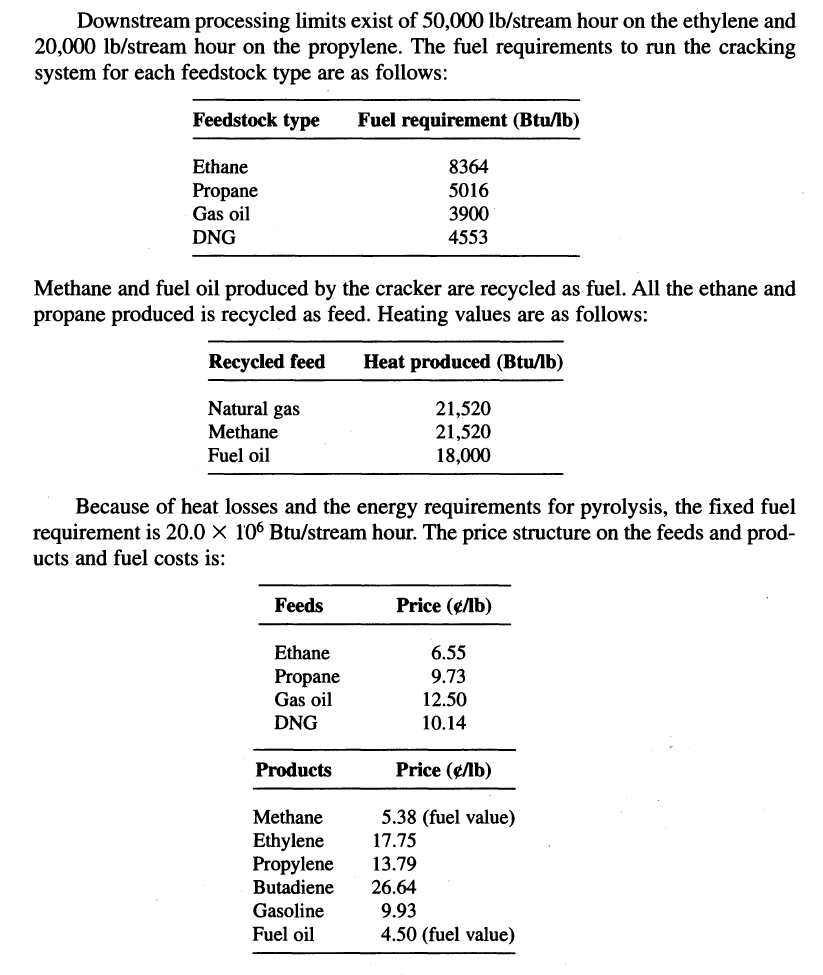

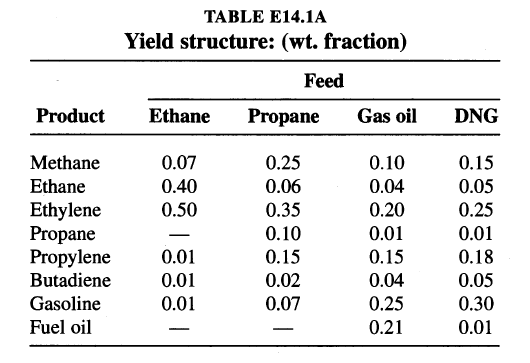

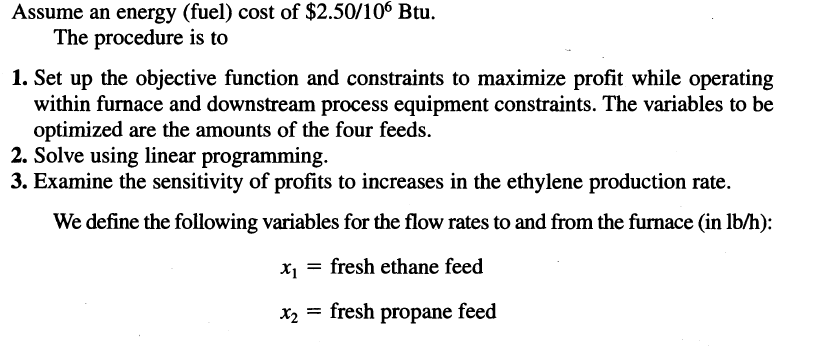

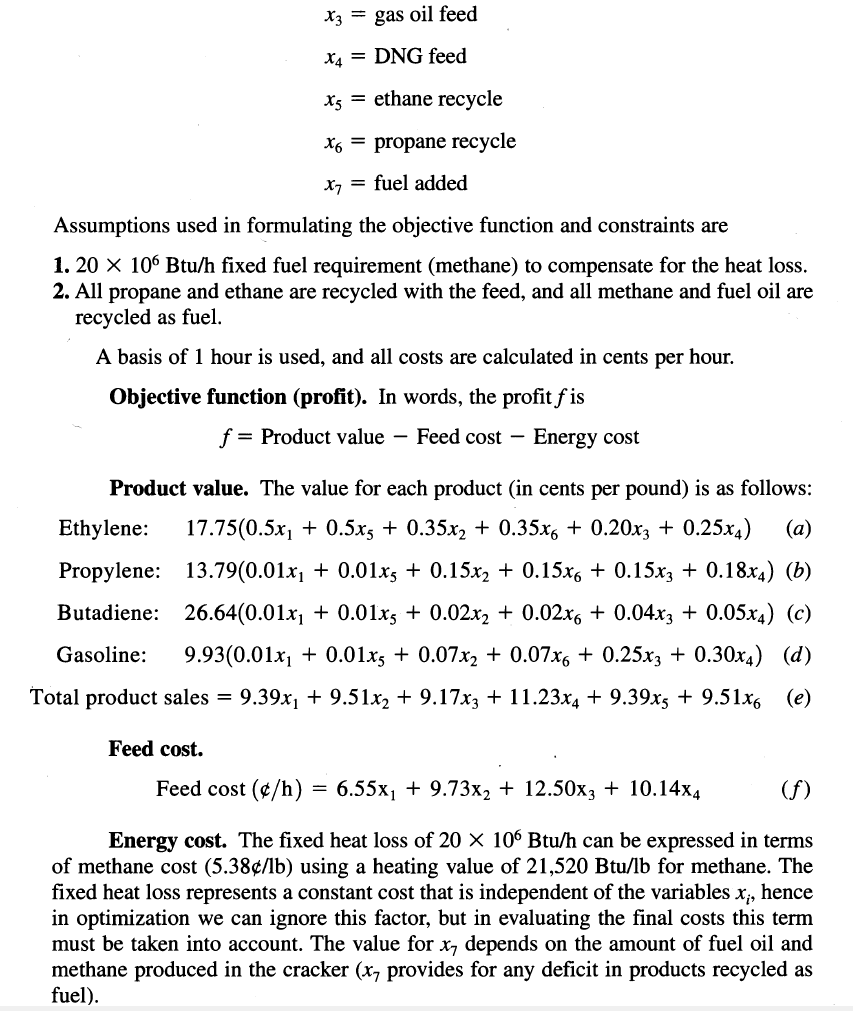

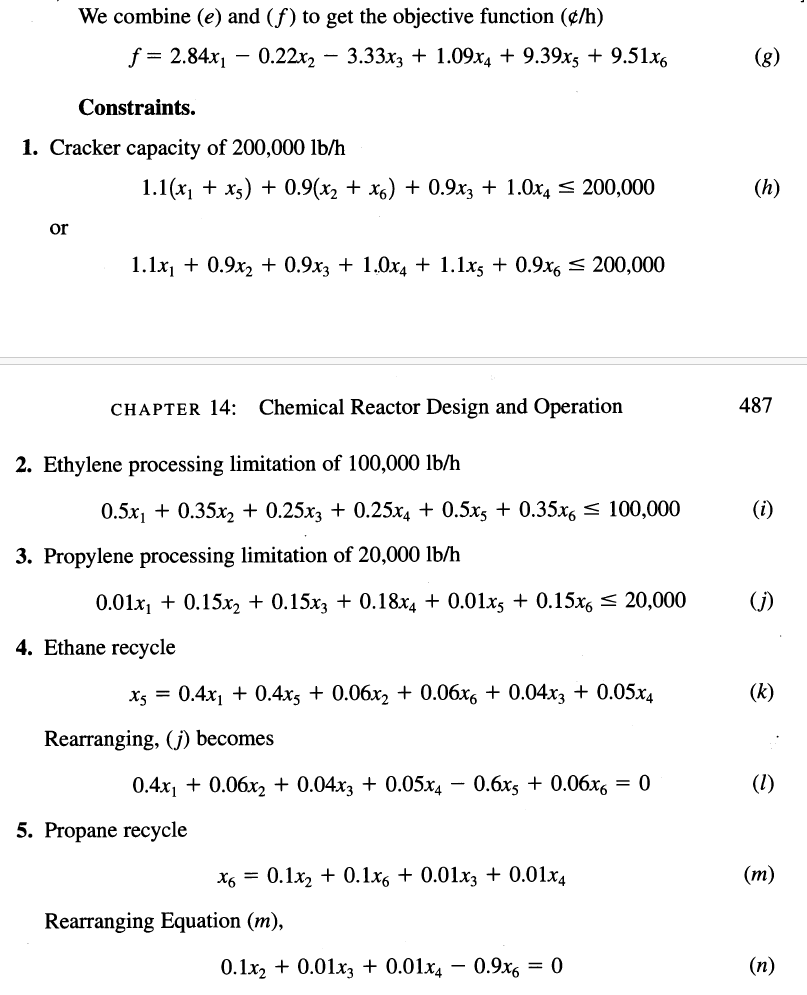

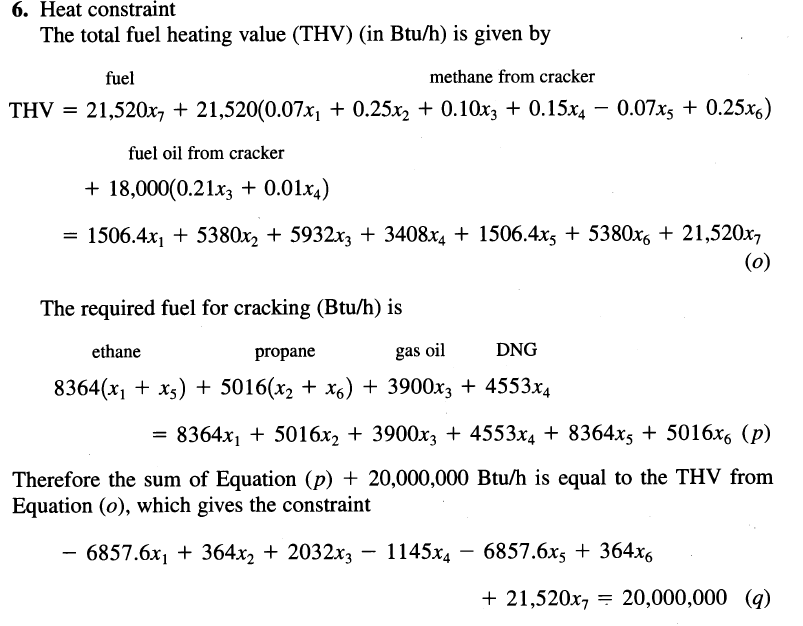

In [1]:
!pip install gurobipy

import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # createa new model
    model = gp.Model("linear_programming")

    # create optimization or decision variables
    x1 = model.addVar(name = 'x1') # fresh ethane feed
    x2 = model.addVar(name = 'x2') # fresh propane feed
    x3 = model.addVar(name = 'x3') # gas oil feed
    x4 = model.addVar(name = 'x4') # DNG feed
    x5 = model.addVar(name = 'x5') # methane recycle
    x6 = model.addVar(name = 'x6') # propane recycle
    x7 = model.addVar(name = 'x7') # fuel added

    stream_map = {
    "x1": "ethane feed",
    "x2": "propane feed",
    "x3": "gas oil feed",
    "x4": "DNG feed",
    "x5": "ethane recycle",
    "x6": "propane recycle",
    "x7": "fuel added"}

    # set objective: minimize
    # profit = product value - feed cost - energy cost
    model.setObjective(2.84*x1 - 0.22*x2 - 3.33*x3 + 1.09*x4 + 9.39*x5 + 9.51*x6, GRB.MAXIMIZE)

    # add constraints

    # cracker capacity of 200000 lb/h
    model.addConstr(1.1*x1 + 0.9*x2 + 0.9*x3 + 1.0*x4 + 1.1*x5 + 0.9*x6 <= 200000, 'c1')
    # ethylene processing limitation of100000 lb/h
    model.addConstr(0.5*x1 + 0.35*x2 + 0.25*x3 + 0.25*x4 + 0.5*x5 + 0.35*x6 <= 50000, 'c2')
    # propylene processing limitation of 20000 lb/h
    model.addConstr(0.01*x1 + 0.15*x2 + 0.15*x3 + 0.18*x4 + 0.01*x5 + 0.15*x6 <= 20000, 'c3')
    # ethane recycle
    model.addConstr(0.4*x1 + 0.06*x2 + 0.04*x3 + 0.05*x4 - 0.6*x5 + 0.06*x6 == 0, 'c4')
    # propane recycle
    model.addConstr(0.1*x2 + 0.01*x3 + 0.01*x4 - 0.9*x6 == 0, 'c5')
    # heat constraint
    model.addConstr(-6857.6*x1 + 364*x2 + 2032*x3 - 1145*x4 - 6857.6*x5 + 364*x6 + 21520*x7 == 20000000, 'c6')

    model.setParam('Method',0)
    model.setParam('Threads',1)

    # optimize model
    model.optimize()

    vars_dict = {}

    print("-"*40)
    print(f"{'stream':<25} {'flowrate (lb/h)':>15}")
    print("-"*40)

    for v in model.getVars():
        vars_dict[v.VarName] = v.X # Populate vars_dict with each variable's optimal value
        label = f"{v.VarName} ({stream_map[v.VarName]})"
        print(f"{label:<25} {v.X:>15.1f}")

    print("-"*40)

    obj_val = model.ObjVal
    final_obj_val = obj_val - 5.38*vars_dict['x7']
    print(f"Final Objective Value: {final_obj_val}")
    # print(f"Obj: {model.ObjVal:g}")
    print(f"Method used is {model.params.Method}")
    print(f"status {model.Status}")

except gp.GurobiError as e:
    print(f"Error code {e.errno}: {e}")

except AttributeError:
    print("Encountered an attribute error")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 51.8 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Set parameter Method to value 0
Set parameter Threads to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 1 threads

Non-default parameters:
Method  0
Threads  1

Optimize a model with 6 rows, 7 columns and 35 nonzeros (Max)
Model fingerprint: 0xb51fccfa
Model has 6 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-02, 2e+04]
  Objective range  [2e-01, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+04, 2e+07]
Presolve removed 0 rows and 1 columns
Presolve time: 0.01s
Presolved: 6 rows, 6 columns, 34 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -0.0000000e+00   0.000000e+00   1.